# PPR global validation

This notebook validates all 66 LMEs and 18 High Seas units using the Sea Around Us definitions. Catch includes landings and discards, reported and unreported, for the latest year shared by every archive.

Only the approved Pauly-Christensen trophic-chain calculation is used:

\[
SPPR = 10^{TL-1}
\]

\[
PPR = Catch_{tonnes} \times SPPR
\]

The separate wet-weight-to-carbon divisor of 9 is intentionally omitted. PPR is reported in tonnes of primary-production equivalent.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'global_output' / 'tables').exists():
    ROOT = ROOT.parent
TABLES = ROOT / 'global_output' / 'tables'
metadata = json.loads((TABLES / 'run_metadata.json').read_text())
print(f"Scope: {metadata['scope']} | Units: {metadata['unit_count']} | Year: {metadata['year']} | TE: {metadata['transfer_efficiency']}")

Scope: all Sea Around Us LMEs and High Seas units | Units: 84 | Year: 2019 | TE: 0.1


## Global ranking and catch totals

,rank_global_ppr,unit_id,region_name,region_type,year,total_catch_tonnes,catch_tl_coverage_fraction,ppr_species,fraction_global_ppr
0,1,LME_036,South China Sea,LME,2019,1.110167e+07,1.0,8.070991e+09,0.123688
1,2,LME_032,Arabian Sea,LME,2019,5.436429e+06,1.0,4.734727e+09,0.072560
2,3,LME_034,Bay of Bengal,LME,2019,6.697726e+06,1.0,3.525462e+09,0.054028
3,4,LME_047,East China Sea,LME,2019,5.649830e+06,1.0,3.396645e+09,0.052054
4,5,LME_052,Sea of Okhotsk,LME,2019,4.800852e+06,1.0,2.799543e+09,0.042903
5,6,LME_013,Humboldt Current,LME,2019,7.390381e+06,1.0,2.612053e+09,0.040030
6,7,LME_027,Canary Current,LME,2019,5.771015e+06,1.0,2.359485e+09,0.036159
7,8,LME_028,Guinea Current,LME,2019,4.469155e+06,1.0,2.256399e+09,0.034579
8,9,HS_077,"Pacific, Eastern Central",High Seas,2019,8.606712e+05,1.0,2.196179e+09,0.033657
9,10,LME_035,Gulf of Thailand,LME,2019,2.615825e+06,1.0,1.868894e+09,0.028641


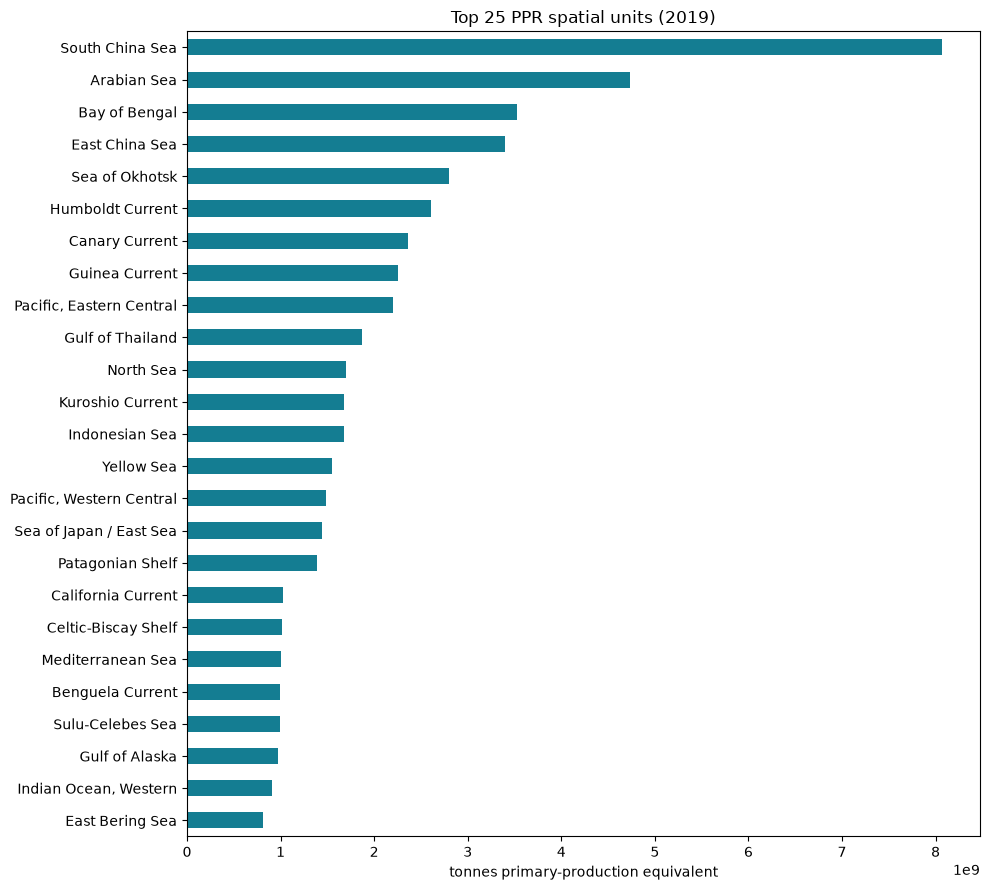

,region_type,units,catch_tonnes,ppr
0,High Seas,18,3.822570e+06,7.375990e+09
1,LME,66,9.529312e+07,5.787669e+10


In [2]:
summary = pd.read_csv(TABLES / 'global_summary.csv')
display(summary[['rank_global_ppr', 'unit_id', 'region_name', 'region_type', 'year',
                 'total_catch_tonnes', 'catch_tl_coverage_fraction', 'ppr_species',
                 'fraction_global_ppr']].head(25))

top = summary.nsmallest(25, 'rank_global_ppr').sort_values('ppr_species')
ax = top.plot.barh(x='region_name', y='ppr_species', legend=False,
                   color='#147D92', figsize=(10, 9))
ax.set_title(f"Top 25 PPR spatial units ({metadata['year']})")
ax.set_xlabel('tonnes primary-production equivalent')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

display(summary.groupby('region_type', as_index=False).agg(
    units=('unit_id', 'size'), catch_tonnes=('total_catch_tonnes', 'sum'),
    ppr=('ppr_species', 'sum')))

## Catch and aggregation reconciliation

In [3]:
validation = pd.read_csv(TABLES / 'validation.csv')
boolean_names = ['catch_reconciled', 'commercial_ppr_reconciled', 'functional_ppr_reconciled']
boolean_checks = validation[validation['check'].isin(boolean_names)].copy()
boolean_checks['passed'] = boolean_checks['value'].astype(str).str.lower().isin(['true', '1', '1.0'])
violation_checks = validation[validation['check'].str.endswith('jensen_violations')].copy()
violation_checks['value_numeric'] = pd.to_numeric(violation_checks['value'])
display(boolean_checks.groupby('check')['passed'].agg(['sum', 'count']))
display(violation_checks.groupby('check')['value_numeric'].agg(['sum', 'max']))
assert boolean_checks['passed'].all()
assert violation_checks['value_numeric'].eq(0).all()

,sum,count
check,,
catch_reconciled,84,84
commercial_ppr_reconciled,84,84
functional_ppr_reconciled,84,84


,sum,max
check,,
commercial_jensen_violations,0,0
functional_jensen_violations,0,0


## Trophic-level matching coverage

,match_method,tl_source,match_confidence,taxa_rows,catch_tonnes,catch_fraction_global
1,exact_sea_around_us,Sea Around Us exploited organisms,high,7301,5.283413e+07,0.533055
0,exact_2020_supplement,2020 supplement MeanTL,high,6962,4.628155e+07,0.466945


,unit_id,region_name,region_type,catch_tl_coverage_fraction,missing_tl_catch_tonnes,taxa_count,matched_taxa_count
0,LME_036,South China Sea,LME,1.0,0.0,340,340
1,LME_032,Arabian Sea,LME,1.0,0.0,393,393
2,LME_034,Bay of Bengal,LME,1.0,0.0,288,288
3,LME_047,East China Sea,LME,1.0,0.0,254,254
4,LME_052,Sea of Okhotsk,LME,1.0,0.0,131,131
5,LME_013,Humboldt Current,LME,1.0,0.0,184,184
6,LME_027,Canary Current,LME,1.0,0.0,412,412
7,LME_028,Guinea Current,LME,1.0,0.0,325,325
8,HS_077,"Pacific, Eastern Central",High Seas,1.0,0.0,26,26
9,LME_035,Gulf of Thailand,LME,1.0,0.0,214,214


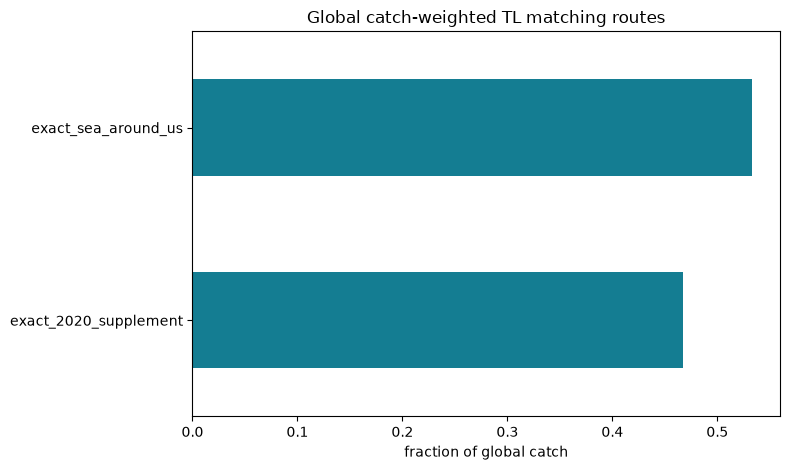

In [4]:
coverage = pd.read_csv(TABLES / 'tl_coverage.csv')
route = coverage.groupby(['match_method', 'tl_source', 'match_confidence'], as_index=False).agg(
    taxa_rows=('taxa_count', 'sum'), catch_tonnes=('catch_tonnes', 'sum'))
route['catch_fraction_global'] = route['catch_tonnes'] / route['catch_tonnes'].sum()
display(route.sort_values('catch_tonnes', ascending=False))

low_coverage = summary.nsmallest(20, 'catch_tl_coverage_fraction')[
    ['unit_id', 'region_name', 'region_type', 'catch_tl_coverage_fraction',
     'missing_tl_catch_tonnes', 'taxa_count', 'matched_taxa_count']]
display(low_coverage)

route.set_index('match_method')['catch_fraction_global'].sort_values().plot.barh(
    color='#147D92', figsize=(8, 4.8))
plt.title('Global catch-weighted TL matching routes')
plt.xlabel('fraction of global catch')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Correct aggregation versus intentional Jensen-error aggregation

The correct path sums taxon PPR before deriving group SPPR. The comparison path deliberately averages trophic level by catch before exponentiating. Convexity requires correct PPR to be at least the Jensen-error result, apart from numerical tolerance.

In [5]:
jensen = pd.read_csv(TABLES / 'jensen_comparison.csv')
global_bias = jensen.groupby('classification', as_index=False).agg(
    ppr_correct=('ppr_correct', 'sum'), ppr_jensen=('ppr_jensen', 'sum'))
global_bias['underestimate_fraction'] = 1 - global_bias['ppr_jensen'] / global_bias['ppr_correct']
display(global_bias)

regional_bias = jensen.groupby(['unit_id', 'region_name', 'classification'], as_index=False).agg(
    ppr_correct=('ppr_correct', 'sum'), ppr_jensen=('ppr_jensen', 'sum'))
regional_bias['underestimate_fraction'] = 1 - regional_bias['ppr_jensen'] / regional_bias['ppr_correct']
display(regional_bias.nlargest(25, 'underestimate_fraction'))

,classification,ppr_correct,ppr_jensen,underestimate_fraction
0,commercial,6.525268e+10,5.029033e+10,0.229299
1,functional,6.525268e+10,5.449906e+10,0.164800


,unit_id,region_name,classification,ppr_correct,ppr_jensen,underestimate_fraction
126,LME_047,East China Sea,commercial,3.396645e+09,2.016011e+09,0.406470
128,LME_048,Yellow Sea,commercial,1.554215e+09,9.399680e+08,0.395213
44,LME_006,Southeast U.S. Continental Shelf,commercial,1.044388e+08,6.562292e+07,0.371661
42,LME_005,Gulf of Mexico,commercial,5.583617e+08,3.528502e+08,0.368062
104,LME_036,South China Sea,commercial,8.070991e+09,5.121240e+09,0.365476
66,LME_017,North Brazil Shelf,commercial,2.925733e+08,1.891670e+08,0.353437
110,LME_039,North Australian Shelf,commercial,3.260992e+07,2.130623e+07,0.346633
98,LME_033,Red Sea,commercial,1.140711e+08,7.467461e+07,0.345368
64,LME_016,East Brazil Shelf,commercial,2.016581e+08,1.323798e+08,0.343543
114,LME_041,East-Central Australian Shelf,commercial,3.215435e+07,2.122726e+07,0.339833


## Final validation gate

In [6]:
assert len(summary) == metadata['unit_count'] == 84
assert summary['year'].nunique() == 1
positive_catch = summary['total_catch_tonnes'] > 0
assert summary.loc[positive_catch, 'catch_tl_coverage_fraction'].between(0, 1).all()
assert summary.loc[~positive_catch, 'catch_tl_coverage_fraction'].isna().all()
assert (summary['ppr_species'] - summary['ppr_commercial_correct']).abs().max() < 1e-4
assert (summary['ppr_species'] - summary['ppr_functional_correct']).abs().max() < 1e-4
assert summary['rank_global_ppr'].tolist() == list(range(1, len(summary) + 1))
assert abs(summary['fraction_global_ppr'].sum() - 1.0) < 1e-10
print('All global validation gates passed.')

All global validation gates passed.


## Sources

- Sea Around Us catch and spatial data: https://www.seaaroundus.org/data/
- Sea Around Us tools/download guide: https://www.seaaroundus.org/tools-guide/
- Pauly, D. & Christensen, V. (1995), *Primary production required to sustain global fisheries*, Nature 374:255-257.
- Luong et al. (2020) supplementary workbook is used only for `MeanTL`; its alternative SPPR estimates are not used.